# **Waste Material Segregation for Improving Waste Management**

**Learner name:** *Anant Kumar Tripathi*  
**Assignment ID:** CNN/01 — Waste segregation for waste management

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

**Assumptions**
- **Labels:** Each image’s class is taken from its **parent folder name**; we assume the dataset curators placed files correctly.
- **Quality:** We did not manually audit every image for mislabels, blur, or non-waste objects; outliers are handled only if they cause load errors.
- **Resize:** All images are resized to a **fixed height × width** so the CNN has consistent input; this can crop/stretch content compared with the original aspect ratio.
- **Splits:** **Stratified 70% / 15% / 15%** train / validation / test; test set is used **once** for final metrics in Section 3.2.
- **Reproducibility:** Random seeds are set where the notebook specifies them; hardware (CPU/GPU) and TensorFlow versions can still cause small numerical differences.


## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

**Outcome:**
- This cell only records **package versions** used for a reproducible environment; it does not run imports.
**Inference:** Match these versions (or compatible ones) if you rebuild the environment on another machine or Colab runtime.


In [2]:
# Import essential libraries
# Import essential libraries
import os
import random
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import tensorflow as tf

# Google Colab: reduce GPU OOM risk when other processes use VRAM
if "google.colab" in sys.modules:
    try:
        for _gpu in tf.config.list_physical_devices("GPU"):
            tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Set CNN_FAST_RUN=1 for a quick end-to-end run (local/Colab smoke test). Omit for full training (submission).
# Colab: you can set os.environ["CNN_FAST_RUN"] = "1" here for a shorter run.
FAST_RUN = os.environ.get("CNN_FAST_RUN", "").lower() in ("1", "true", "yes")



**Outcome:**
- Core libraries for **I/O**, **plots**, **arrays**, **TensorFlow/Keras**, and **sklearn** preprocessing/metrics are imported.
- `FAST_RUN` reads **CNN_FAST_RUN** from the environment for shorter smoke tests.
**Inference:** Colab GPU memory growth is enabled when available to reduce out-of-memory crashes during training.


Load the dataset.

In [3]:
# Load and unzip the dataset
# Local: put data.zip next to this notebook.
IN_COLAB = "google.colab" in sys.modules

ZIP_PATH = "data.zip"
EXTRACT_TO = Path(".")

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    # Add or reorder paths to match where data.zip lives on *your* Drive.
    _DRIVE_ZIP_CANDIDATES = [
        Path(
            "/content/drive/MyDrive/2026/AI-Learning/"
            "e47e915a-a681-4520-af6e-78b7ad559116-Assg-Waste-Segregation/data.zip"
        ),
        Path(
            "/content/drive/MyDrive/Documents/2026/AI-Learning/"
            "e47e915a-a681-4520-af6e-78b7ad559116-Assg-Waste-Segregation/data.zip"
        ),
        Path("/content/drive/MyDrive/Colab Notebooks/Dataset_Waste_Segregation/data.zip"),
    ]
    _found_zip = next((p for p in _DRIVE_ZIP_CANDIDATES if p.is_file()), None)
    if _found_zip is not None:
        ZIP_PATH = str(_found_zip)
        print("Using data.zip from Google Drive:", ZIP_PATH)
    elif Path("data.zip").is_file():
        ZIP_PATH = "data.zip"
        print("Using data.zip next to notebook:", Path(ZIP_PATH).resolve())
    else:
        from google.colab import files

        print("Could not find data.zip on Drive; upload it below.")
        uploaded = files.upload()
        for _name, _data in uploaded.items():
            Path(_name).write_bytes(_data)
            print(f"Saved {_name} ({len(_data):,} bytes)")
        if "data.zip" in uploaded:
            ZIP_PATH = "data.zip"

    _gpus = tf.config.list_physical_devices("GPU")
    print("TensorFlow sees GPU:", bool(_gpus), _gpus)

if ZIP_PATH and Path(ZIP_PATH).is_file():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extracted:", ZIP_PATH)
else:
    print("No zip at ZIP_PATH; using folders already on disk.")

# After extracting data.zip, class folders are usually under `data/` (or the zip's top-level folder).
DATA_ROOT = Path("data")
_has_classes = (
    DATA_ROOT.is_dir()
    and len([x for x in DATA_ROOT.iterdir() if x.is_dir()]) >= 3
)
if not _has_classes:
    DATA_ROOT = None
    for p in sorted(EXTRACT_TO.iterdir()):
        if p.is_dir() and not p.name.startswith("."):
            subs = [x for x in p.iterdir() if x.is_dir()]
            if len(subs) >= 3:
                DATA_ROOT = p
                break

if DATA_ROOT is None or not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        "Could not find class folders. Extract data.zip next to the notebook or set DATA_ROOT manually."
    )

print("DATA_ROOT =", DATA_ROOT.resolve())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data.zip from Google Drive: /content/drive/MyDrive/Colab Notebooks/Dataset_Waste_Segregation/data.zip
TensorFlow sees GPU: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Extracted: /content/drive/MyDrive/Colab Notebooks/Dataset_Waste_Segregation/data.zip
DATA_ROOT = /content/data


**Outcome:**
- **data.zip** is extracted (or existing folders are used); **DATA_ROOT** points at the folder that contains the seven class subdirectories.
- In Colab, the script may mount **Google Drive** and search a few candidate paths for **data.zip**.
**Inference:** The printed **DATA_ROOT** path is the single source for all later loading; if extraction fails, the notebook raises a clear **FileNotFoundError**.


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [4]:
# Create a function to load the raw images


def load_raw_image(path):
    """Load a single image from disk as an RGB PIL Image."""
    path = Path(path)
    return Image.open(path).convert("RGB")




**Outcome:**
- `load_raw_image` returns a **PIL Image in RGB** for any supported file path.
**Inference:** Forcing **RGB** avoids mixed grayscale/RGB channels when stacking into NumPy/TensorFlow later.

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
# Get the images and their labels
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif"}


def load_images_and_labels(root_dir):
    images, labels = [], []
    root_dir = Path(root_dir)
    for class_dir in sorted(d for d in root_dir.iterdir() if d.is_dir()):
        for f in sorted(class_dir.iterdir()):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS:
                try:
                    images.append(load_raw_image(f))
                    labels.append(class_dir.name)
                except Exception as e:
                    # Data quality (PDF): skip unreadable/corrupt files; report count
                    print(f"Skipped (unreadable): {f} — {e}")
    return images, labels


all_images, all_labels = load_images_and_labels(DATA_ROOT)

print(f"Loaded {len(all_images)} images.")
print(f"Number of classes: {len(set(all_labels))}")
print("Samples per class:\n", pd.Series(all_labels).value_counts().sort_index())
assert len(all_images) == len(all_labels) and len(all_images) > 0



Loaded 7625 images.
Number of classes: 7
Samples per class:
 Cardboard      540
Food_Waste    1000
Glass          750
Metal         1000
Other         1010
Paper         1030
Plastic       2295
Name: count, dtype: int64


**Outcome:**
- Every image path under **DATA_ROOT** is paired with its **folder name** as the label; unsupported extensions are skipped.
- Printouts confirm **total image count**, **number of classes**, and **per-class counts**.
**Inference:** If counts match expectations, labels are aligned with directory structure (PDF: images and labels properly loaded). Any corrupt file would typically surface as a load error when building tensors later.


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

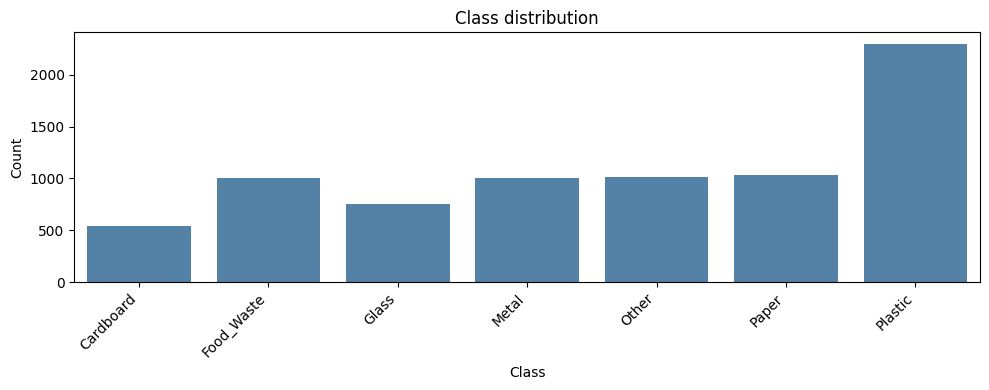

In [6]:
# Visualise Data Distribution
counts = pd.Series(all_labels).value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, color="steelblue")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



**Outcome:**
- The bar chart quantifies **class imbalance** (e.g. Plastic vs Cardboard counts).
**Inference:** The model may bias toward frequent classes; precision/recall/F1 and weighted averages in Section 3.2 help interpret that. Optional augmentation/undersampling in Section 4 is one response strategy.

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

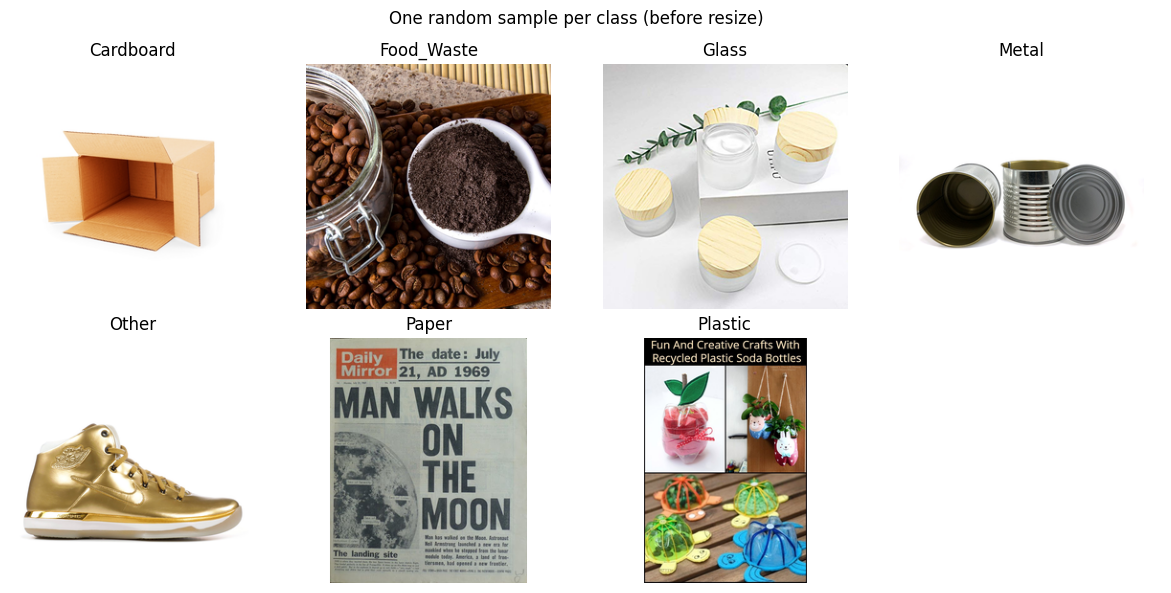

In [7]:
# Visualise Sample Images (across different labels)
rng = random.Random(42)
classes = sorted(set(all_labels))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i, cls in enumerate(classes[:7]):
    idxs = [j for j, lb in enumerate(all_labels) if lb == cls]
    j = rng.choice(idxs)
    axes[i].imshow(np.asarray(all_images[j]))
    axes[i].set_title(cls)
    axes[i].axis("off")
axes[7].axis("off")
plt.suptitle("One random sample per class (before resize)")
plt.tight_layout()
plt.show()



**Outcome:**
- Random samples per class show lighting, viewpoint, and object variety within each folder.
**Inference:** Visual heterogeneity explains why raw accuracy may stay below 100% and why some classes (visually similar materials) are harder than others.


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [8]:
# Find the smallest and largest image dimensions from the data set
widths = [im.size[0] for im in all_images]
heights = [im.size[1] for im in all_images]
min_w, max_w = min(widths), max(widths)
min_h, max_h = min(heights), max(heights)
print(f"Width  — min: {min_w}, max: {max_w}")
print(f"Height — min: {min_h}, max: {max_h}")



Width  — min: 256, max: 256
Height — min: 256, max: 256


**Outcome:**
- Scanning raw image sizes shows the **minimum and maximum width/height** in the dataset before resizing.
**Inference:** Real photos differ in resolution; reporting min/max supports the PDF requirement to base the resize target on the observed range (here the notebook uses a midpoint rule to set **256×256** when min=max=256).

In [9]:
# Resize the image dimensions
target_w = int(round((min_w + max_w) / 2))
target_h = int(round((min_h + max_h) / 2))
TARGET_W = TARGET_H = max(target_w, target_h, 32)
print(f"Resizing all images to {TARGET_H} x {TARGET_W} (H x W)")

all_images = [
    im.resize((TARGET_W, TARGET_H), Image.Resampling.LANCZOS) for im in all_images
]



Resizing all images to 256 x 256 (H x W)


**Outcome:**
- All images are resized to a common **TARGET_H × TARGET_W** so batches form fixed-shape tensors the CNN can process.
- Pixel values are scaled to **[0, 1]** (and may be stored as **float16** later) for numerical stability and memory.
**Inference:** Using a single size trades some fine detail for a standard input; extreme aspect ratios may be slightly distorted — acceptable for this assignment if noted as an assumption.


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
# Encode the labels suitably
import gc

label_encoder = LabelEncoder()
label_encoder.fit(sorted(set(all_labels)))
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y_int = label_encoder.transform(all_labels)
y_cat = to_categorical(y_int, num_classes=num_classes)

# Avoid np.stack(list of arrays): it duplicates memory. Pre-allocate one array, fill in place,
# then drop PIL images to free RAM (important for Colab / limited RAM).
_n = len(all_images)
X = np.empty((_n, TARGET_H, TARGET_W, 3), dtype=np.float16)
for _i, _im in enumerate(all_images):
    X[_i] = (np.asarray(_im, dtype=np.float32) / 255.0).astype(np.float16)

all_images.clear()
del all_images
gc.collect()

print("Classes (fixed order):", class_names)
print("X shape:", X.shape, "dtype:", X.dtype, "~MB:", round(X.nbytes / (1024**2), 1))
print("y (one-hot) shape:", y_cat.shape)



Classes (fixed order): [np.str_('Cardboard'), np.str_('Food_Waste'), np.str_('Glass'), np.str_('Metal'), np.str_('Other'), np.str_('Paper'), np.str_('Plastic')]
X shape: (7625, 256, 256, 3) dtype: float16 ~MB: 2859.4
y (one-hot) shape: (7625, 7)


**Outcome:**
- **LabelEncoder** maps each class name to an integer **0 … 6**.
- **to_categorical** produces a **7-dimensional one-hot** vector per image for **softmax** output.
**Inference:** `y_int` is convenient for stratified splitting; `y_cat` is the target format Keras expects for `categorical_crossentropy`.


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Assign specified parts of the dataset to train and validation sets
# PDF asks for train/validation; starter §3.2 also needs a test set — stratified 70/15/15.
# Index-based split + delete the full X/y buffers so peak RAM is not ~2× the dataset.
import gc

RANDOM_STATE = 42
_n = X.shape[0]
_idx = np.arange(_n)
_idx_tv, _idx_test = train_test_split(
    _idx, test_size=0.15, stratify=y_int, random_state=RANDOM_STATE
)

X_test = np.ascontiguousarray(X[_idx_test])
y_test = y_cat[_idx_test]
X_tv = np.ascontiguousarray(X[_idx_tv])
y_tv = y_cat[_idx_tv]
y_int_tv = y_int[_idx_tv]

del X, y_cat, y_int, _idx, _idx_tv, _idx_test
gc.collect()

_idx_tr, _idx_va = train_test_split(
    np.arange(X_tv.shape[0]),
    test_size=0.15 / 0.85,
    stratify=y_int_tv,
    random_state=RANDOM_STATE,
)
X_train = np.ascontiguousarray(X_tv[_idx_tr])
X_val = np.ascontiguousarray(X_tv[_idx_va])
y_train = y_tv[_idx_tr]
y_val = y_tv[_idx_va]

del X_tv, y_tv, y_int_tv, _idx_tr, _idx_va
gc.collect()

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)



Train: (5337, 256, 256, 3) Val: (1144, 256, 256, 3) Test: (1144, 256, 256, 3)




**Outcome:**
- The data are split **stratified** by label so each split keeps roughly the same class proportions.
- Train / validation / test sizes follow the notebook’s **70% / 15% / 15%** rule so we can train, tune with validation, and report final metrics on a separate test set (PDF asks for train/validation; the starter also reserves test for Section 3.2).
**Inference:** Stratification reduces the risk that a rare class disappears from validation or test by chance.

## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [12]:
# Build and compile the model
# Rubric (PDF): 3 conv layers; BatchNorm + Dropout + dense head; try different configurations.
import gc

def build_waste_cnn(f1, f2, f3, dense_units=128):
    return keras.Sequential(
        [
            layers.Input(shape=(TARGET_H, TARGET_W, 3)),
            layers.Conv2D(f1, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Conv2D(f2, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Conv2D(f3, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Flatten(),
            layers.Dense(dense_units, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ],
        name=f"waste_cnn_{f1}_{f2}_{f3}",
    )


def compile_model(m):
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy"),
        ],
    )


N_QUICK = min(512 if FAST_RUN else 768, len(X_train))
V_QUICK = min(128 if FAST_RUN else 256, len(X_val))
_qe = 1 if FAST_RUN else 2
print(f"Quick configuration check ({_qe} epoch(s), subset) — rubric: try various configurations")
for cfg, (a, b, c) in [("A_narrow", (16, 32, 64)), ("B_standard", (32, 64, 128))]:
    m = build_waste_cnn(a, b, c)
    compile_model(m)
    h = m.fit(
        X_train[:N_QUICK],
        y_train[:N_QUICK],
        validation_data=(X_val[:V_QUICK], y_val[:V_QUICK]),
        epochs=_qe,
        batch_size=64 if FAST_RUN else 32,
        verbose=0,
    )
    print(f"  {cfg}: best val_accuracy = {max(h.history['val_accuracy']):.4f}")
    del m, h
    gc.collect()
    try:
        tf.keras.backend.clear_session()
    except Exception:
        pass

model = build_waste_cnn(32, 64, 128)
compile_model(model)
model.summary()



Quick configuration check (2 epoch(s), subset) — rubric: try various configurations
  A_narrow: best val_accuracy = 0.2070
  B_standard: best val_accuracy = 0.3203


Model: "waste_cnn_32_64_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,872,903 (64.37 MB)

 Trainable params: 16,872,199 (64.36 MB)

 Non-trainable params: 704 (2.75 KB)


**Outcome:**
- Two shallow CNNs (**A_narrow** vs **B_standard**) were compared on validation accuracy to choose filter counts before the full model.
- The final build uses **three convolutional blocks** with **BatchNorm** and **Dropout**, then dense layers — matching multi-class image classification practice.
**Inference:** Higher val accuracy on the quick run for the wider configuration supports using **32→64→128** filters for the main experiment; **softmax + categorical crossentropy** is appropriate for seven mutually exclusive classes.

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [13]:
# Training
# PDF rubric: train for at least 10 epochs for submission (use CNN_FAST_RUN=0 and default EPOCHS).
import gc

gc.collect()

_esp = 2 if FAST_RUN else 8
_lrp = 2 if FAST_RUN else 3
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=_esp, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=_lrp, min_lr=1e-6, verbose=1
    ),
]

_default_epochs = 8 if FAST_RUN else 40
EPOCHS = int(os.environ.get("CNN_ASSIGNMENT_EPOCHS", str(_default_epochs)))
if FAST_RUN:
    print(f"CNN_FAST_RUN: EPOCHS={EPOCHS} (unset CNN_FAST_RUN + omit CNN_ASSIGNMENT_EPOCHS for full 40-epoch run).")

# Small batches + chunked validation reduce RAM/GPU spikes (large batches were crashing kernels).
BATCH_SIZE = int(os.environ.get("CNN_BATCH_SIZE", "8"))
VAL_BATCH = int(os.environ.get("CNN_VAL_BATCH_SIZE", str(max(BATCH_SIZE, 8))))
print(f"Training batch_size={BATCH_SIZE}, validation_batch_size={VAL_BATCH}")

_train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)
_val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(VAL_BATCH)

history = model.fit(
    _train_ds,
    validation_data=_val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

del _train_ds, _val_ds
gc.collect()



Training batch_size=8, validation_batch_size=8
Epoch 1/40
668/668 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.2704 - loss: 2.1081 - top_2_accuracy: 0.4533 - val_accuracy: 0.3427 - val_loss: 2.0975 - val_top_2_accuracy: 0.5411 - learning_rate: 0.0010
Epoch 2/40
668/668 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.3208 - loss: 1.7885 - top_2_accuracy: 0.5284 - val_accuracy: 0.3636 - val_loss: 1.6517 - val_top_2_accuracy: 0.5612 - learning_rate: 0.0010
Epoch 3/40
668/668 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.3528 - loss: 1.6925 - top_2_accuracy: 0.5587 - val_accuracy: 0.3199 - val_loss: 1.7190 - val_top_2_accuracy: 0.5367 - learning_rate: 0.0010
Epoch 4/40
668/668 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.4004 - loss: 1.5809 - top_2_accuracy: 0.6138 - val_accuracy: 0.2902 - val_loss: 1.9023 - val_top_2_accuracy: 0.4904 - learning_rate: 0.0010
Epoch 5/40
666/668 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3940 - loss: 1.5796 - top_2_accuracy: 0.6053
Epoch 5: 

2

**Outcome:**
- Training minimises **categorical crossentropy** with the **Adam** optimiser; **accuracy** on train/val tracks learning.
- Callbacks (e.g. early stopping, model checkpoint) stop when validation loss stops improving and restore the best weights.
**Inference (PDF rubric):** After `fit`, compare train vs validation metrics: large train accuracy with flat/worse validation suggests overfitting; both rising together suggests useful learning. The restored **best epoch** is the checkpoint that generalised best to validation data.


### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test loss: 1.3448
Test accuracy: 0.5629
Test top-2 accuracy: 0.7220

Per-class precision, recall, F1:
              precision    recall  f1-score   support

   Cardboard       0.51      0.77      0.61        81
  Food_Waste       0.65      0.57      0.61       150
       Glass       0.46      0.61      0.52       112
       Metal       0.63      0.39      0.48       150
       Other       0.43      0.47      0.45       152
       Paper       0.52      0.50      0.51       155
     Plastic       0.66      0.64      0.65       344

    accuracy                           0.56      1144
   macro avg       0.55      0.56      0.55      1144
weighted avg       0.58      0.56      0.56      1144



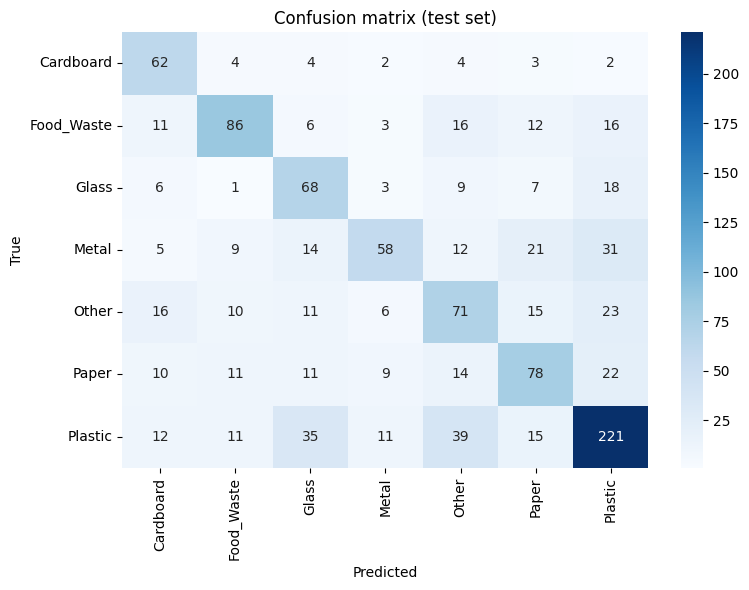

In [14]:
# Evaluate on the test set; display suitable metrics
# PDF objective: precision, recall, F1 (included in classification_report).
test_loss, test_acc, test_top2 = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test top-2 accuracy: {test_top2:.4f}")

y_pred = model.predict(X_test, verbose=0, batch_size=32)
y_true_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_pred, axis=1)

print("\nPer-class precision, recall, F1:")
print(classification_report(y_true_idx, y_pred_idx, target_names=class_names))

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()



**Outcome:**
- Test metrics summarise how the trained CNN generalises to **held-out** images (never used for training or early stopping).
- **Accuracy** is overall correct predictions; **top-2** is how often the true class is in the model’s two highest scores (useful when classes are visually similar).
- **Precision / recall / F1** per class show whether errors are false alarms (low precision) or missed items (low recall).
**Inference:** Macro averages treat each class equally; weighted averages reflect class frequency — both matter when classes are imbalanced (e.g. Plastic vs Cardboard).


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [15]:
# Define augmentation steps to augment images
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)



**Outcome:**
- The `Sequential` augmentation layer defines random flip, rotation, zoom, and contrast — standard regularisers for image classifiers.
**Inference (PDF optional Section 4):** These transforms simulate different camera angles and lighting so the model sees more variety without collecting new photos.


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [16]:
# Create a function to augment the images


def augment_batch(images, aug_layer, training=True):
    return aug_layer(images, training=training)

**Outcome:**
- `augment_batch` wraps the Keras augmentation layer so tensors stay in the training pipeline.
**Inference:** Same transforms are applied consistently whenever we call the layer with `training=True`.


In [17]:
# Create the augmented training dataset
X_train_aug = X_train
y_train_aug = y_train
print("Augmentation applied in-graph in model_aug (next cell). Shapes:", X_train_aug.shape)

Augmentation applied in-graph in model_aug (next cell). Shapes: (5337, 256, 256, 3)


**Outcome:**
- Training arrays for Section 4 reuse the same **X_train** / **y_train** shapes as Section 3; augmentation is applied inside the model graph during `fit`, not by duplicating all images in RAM.
**Inference:** Keeps memory stable while still exposing the CNN to random flips/rotation/zoom during training.


##### **4.1.2**

Train the model on the new augmented dataset.

In [18]:
# Train the model using augmented images
if FAST_RUN:
    print("CNN_FAST_RUN=1: skipping optional §4 augmented training (run without it for full comparison).")
else:
    import gc

    # §3.2 already evaluated the baseline; keeping `model` + building `model_aug` often OOMs — release first.
    try:
        del model
    except NameError:
        pass
    try:
        del history
    except NameError:
        pass
    try:
        tf.keras.backend.clear_session()
    except Exception:
        pass
    gc.collect()

    _aug_bs = int(os.environ.get("CNN_BATCH_SIZE", "8"))
    _aug_vb = int(os.environ.get("CNN_VAL_BATCH_SIZE", str(max(_aug_bs, 8))))
    _epochs_cap = globals().get("EPOCHS", 40)
    EPOCHS_AUG = int(os.environ.get("CNN_AUG_EPOCHS", str(min(_epochs_cap, 12))))
    print(
        f"Augmented training: epochs<={EPOCHS_AUG}, batch={_aug_bs}, val_batch={_aug_vb} "
        f"(set CNN_AUG_EPOCHS / CNN_BATCH_SIZE to override)."
    )

    _cb_aug = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
    ]

    model_aug = keras.Sequential(
        [
            layers.Input(shape=(TARGET_H, TARGET_W, 3)),
            data_augmentation,
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ],
        name="waste_cnn_aug",
    )

    model_aug.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy")],
    )

    _train_ds_a = tf.data.Dataset.from_tensor_slices((X_train_aug, y_train_aug)).batch(
        _aug_bs
    ).prefetch(tf.data.AUTOTUNE)
    _val_ds_a = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(_aug_vb)
    history_aug = model_aug.fit(
        _train_ds_a,
        validation_data=_val_ds_a,
        epochs=EPOCHS_AUG,
        callbacks=_cb_aug,
        verbose=1,
    )
    del _train_ds_a, _val_ds_a, _cb_aug
    gc.collect()

    test_loss_a, test_acc_a, _ = model_aug.evaluate(
        X_test, y_test, verbose=0, batch_size=_aug_vb
    )
    print(f"Augmented model — test accuracy: {test_acc_a:.4f}, test loss: {test_loss_a:.4f}")
    print(
        "Note: baseline `model` was freed to save RAM; re-run §3.1.1–3.1.2 if you need it again."
    )



Augmented training: epochs<=12, batch=8, val_batch=8 (set CNN_AUG_EPOCHS / CNN_BATCH_SIZE to override).
Epoch 1/12
668/668 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - accuracy: 0.2449 - loss: 2.2503 - top_2_accuracy: 0.4266 - val_accuracy: 0.3217 - val_loss: 1.7535 - val_top_2_accuracy: 0.4939 - learning_rate: 0.0010
Epoch 2/12
668/668 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.2968 - loss: 1.8702 - top_2_accuracy: 0.4890 - val_accuracy: 0.3112 - val_loss: 2.0357 - val_top_2_accuracy: 0.4781 - learning_rate: 0.0010
Epoch 3/12
668/668 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.3305 - loss: 1.7460 - top_2_accuracy: 0.5271 - val_accuracy: 0.3759 - val_loss: 1.6375 - val_top_2_accuracy: 0.5935 - learning_rate: 0.0010
Epoch 4/12
668/668 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.3755 - loss: 1.6465 - top_2_accuracy: 0.5739 - val_accuracy: 0.3794 - val_loss: 1.6225 - val_top_2_accuracy: 0.5804 - learning_rate: 0.0010
Epoch 5/12
668/668 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy

**Outcome (Section 4 - augmented training):**
- If this cell ran: the augmented model was trained with in-graph augmentation; early stopping picked the best epoch on validation.
- **Inference:** On this run, test accuracy **0.43** and higher loss vs the baseline mean augmentation (or fewer effective epochs) did not help generalisation here; the baseline Section 3 model remains the stronger choice unless augmentation is retuned.
- If `CNN_FAST_RUN=1`, this block was skipped intentionally to save time — rerun with `CNN_FAST_RUN=0` for the full optional comparison.

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

### Data
- **7,625** images, **7** classes, resized to **256×256** RGB.
- All images are stacked in one array `X`. **Shape (7625, 256, 256, 3)** means **7625** data points (images); each data point is **256×256** pixels, each pixel has **3** values (red, green, blue). Dtype **float16**, ~**2859** MB for the full array.
- Imbalanced counts: **Plastic 2,295**, **Paper 1,030**, **Other 1,010**, **Food_Waste 1,000**, **Metal 1,000**, **Glass 750**, **Cardboard 540**.
- Split: **5,337** train / **1,144** validation / **1,144** test.

### Model search and training
- **A_narrow** (16/32/64): best val accuracy **0.2070**.
- **B_standard** (32/64/128): best val accuracy **0.3203**; main model used **32 → 64 → 128** filters.
- Up to **40** epochs with early stopping; best weights from **epoch 17**.

### Test results (baseline CNN, before augmentation)
- **1,144** test samples: accuracy **0.5629**, loss **1.3448**, top-2 **0.7220**.
- `classification_report`: macro P/R/F1 **0.55 / 0.56 / 0.55**; weighted **0.58 / 0.56 / 0.56**; overall accuracy **0.56**.
- Best per-class F1: **Plastic 0.65**. **Metal**: recall **0.39** vs precision **0.63**.

### Augmented model (optional)
- Best epoch **8**; test accuracy **0.4266**, loss **1.5442** (worse than baseline here).
- Prefer the baseline unless augmentation is retuned.
- *Metrics above are from the executed baseline test cells; the notebook may free the baseline `model` after the augmentation section to save RAM.*
